In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys

sys.path.append('/Users/viduragunawardana/Code/DataScience/Python/dataExplore-2.0/scripts')
import styling
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('../data/train.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# Select features for clustering (exclude target and identifiers)
features_to_exclude = ['patient_id', 'stroke_event', 'Unnamed: 0']
feature_cols = [col for col in df.columns if col not in features_to_exclude]

print(f"\nFeatures for clustering: {feature_cols}")
print(f"Number of features: {len(feature_cols)}")

# Create feature dataframe
X = df[feature_cols].copy()

Dataset shape: (4088, 16)

Columns: ['gender', 'age', 'has_hypertension', 'has_heart_disease', 'marital_status', 'employment_type', 'residence', 'glucose_level', 'bmi_value', 'smoking_habit', 'stroke_event', 'age_group', 'risk_score', 'high_glucose', 'bmi_category', 'lifestyle_risk']

Features for clustering: ['gender', 'age', 'has_hypertension', 'has_heart_disease', 'marital_status', 'employment_type', 'residence', 'glucose_level', 'bmi_value', 'smoking_habit', 'age_group', 'risk_score', 'high_glucose', 'bmi_category', 'lifestyle_risk']
Number of features: 15


In [9]:
numerical_cols = ['age', 'glucose_level', 'bmi_value', 'risk_score']
categorical_cols = [col for col in feature_cols if col not in numerical_cols]

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Handle categorical variables - convert to numeric
for col in categorical_cols:
    if X[col].dtype == 'object' or X[col].dtype == 'bool':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# Handle missing values
X = X.fillna(X.median())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"\nPreprocessed data shape: {X_scaled.shape}")
print(f"Missing values: {X_scaled.isnull().sum().sum()}")


Numerical columns: ['age', 'glucose_level', 'bmi_value', 'risk_score']
Categorical columns: ['gender', 'has_hypertension', 'has_heart_disease', 'marital_status', 'employment_type', 'residence', 'smoking_habit', 'age_group', 'high_glucose', 'bmi_category', 'lifestyle_risk']

Preprocessed data shape: (4088, 15)
Missing values: 0


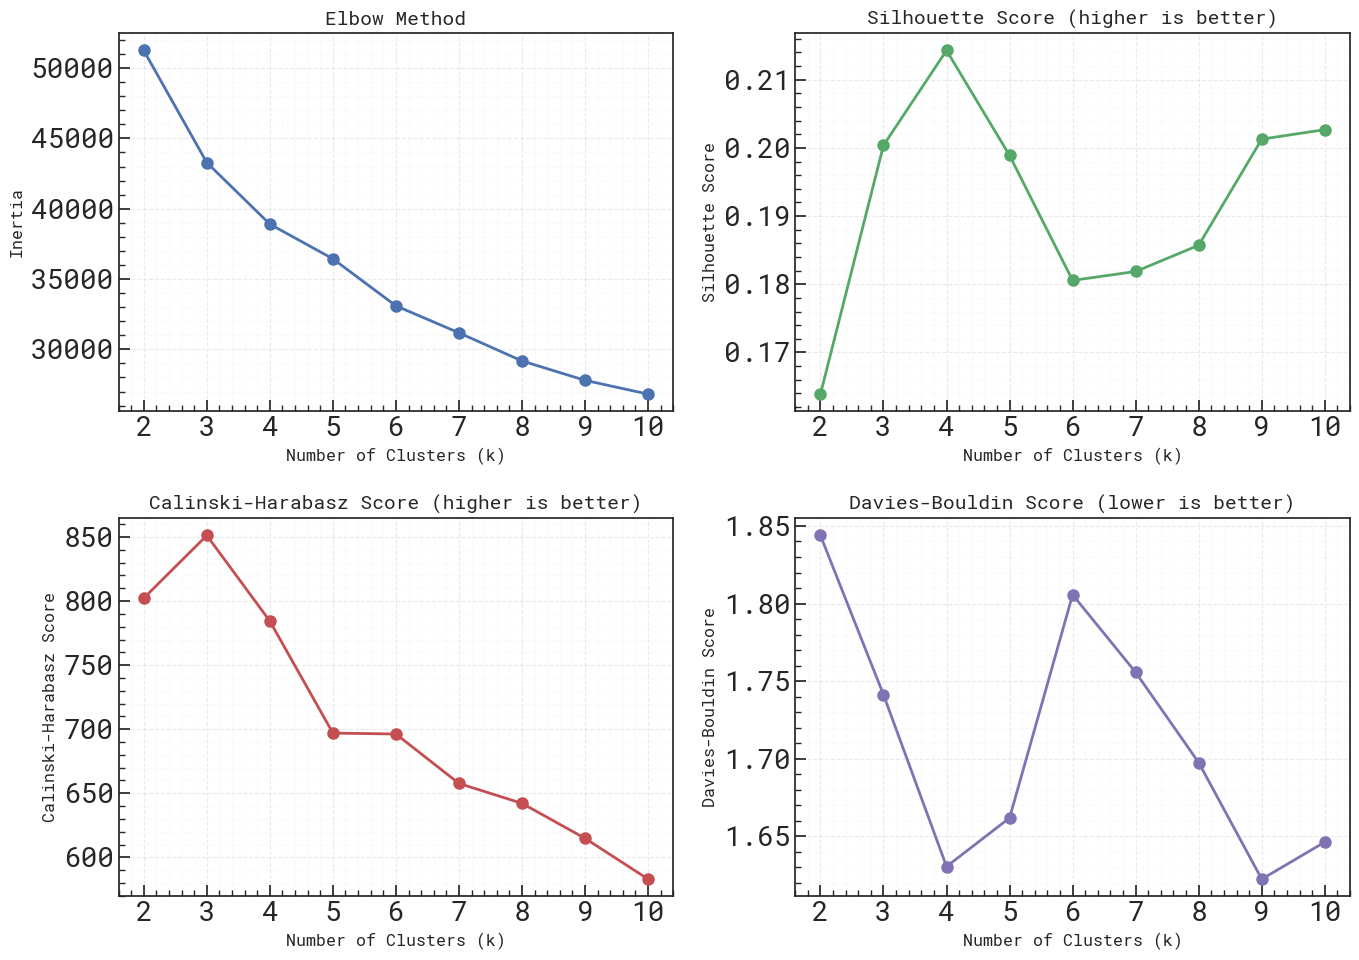

In [10]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    calinski_scores.append(calinski_harabasz_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

# Plot evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow curve
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14)
axes[0, 0].set_xticks(list(k_range))
styling.style_ax(axes[0, 0])

# Silhouette score
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (higher is better)', fontsize=14)
axes[0, 1].set_xticks(list(k_range))
styling.style_ax(axes[0, 1])

# Calinski-Harabasz score
axes[1, 0].plot(k_range, calinski_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 0].set_title('Calinski-Harabasz Score (higher is better)', fontsize=14)
axes[1, 0].set_xticks(list(k_range))
styling.style_ax(axes[1, 0])

# Davies-Bouldin score
axes[1, 1].plot(k_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[1, 1].set_title('Davies-Bouldin Score (lower is better)', fontsize=14)
axes[1, 1].set_xticks(list(k_range))
styling.style_ax(axes[1, 1])

plt.tight_layout()
plt.savefig('cluster_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
eval_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_bouldin_scores
})
print("\nCluster Evaluation Metrics:")
print(eval_df.to_string(index=False))

# Select optimal k (based on silhouette score)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters (by Silhouette): {optimal_k}")


Cluster Evaluation Metrics:
 k      Inertia  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2 51255.880859    0.163887         802.288247        1.843877
 3 43281.966979    0.200376         851.224771        1.741262
 4 38904.113627    0.214292         784.377036        1.630623
 5 36438.971090    0.198891         696.982091        1.661907
 6 33095.070703    0.180563         696.261763        1.805676
 7 31175.431208    0.181874         657.675935        1.755700
 8 29175.638507    0.185722         642.167211        1.697558
 9 27798.286503    0.201281         614.853857        1.622491
10 26815.907123    0.202679         583.019168        1.646377

Optimal number of clusters (by Silhouette): 4


In [12]:
# K-Means Clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['cluster'] = cluster_labels

# Print cluster distribution
print(f"\nCluster Distribution:")
print(df['cluster'].value_counts().sort_index())


Cluster Distribution:
cluster
0    2006
1    1104
2     494
3     484
Name: count, dtype: int64


In [13]:
cluster_profiles = df.groupby('cluster')[numerical_cols].mean()
print("\nCluster Profiles (Numerical Variables - Mean):")
print(cluster_profiles.round(2).to_string())

# Categorical distributions by cluster
print("\nCategorical Variables by Cluster (%):")
for col in categorical_cols:
    ct = pd.crosstab(df['cluster'], df[col], normalize='index') * 100
    print(f"\n{col}:")
    print(ct.round(1).to_string())


Cluster Profiles (Numerical Variables - Mean):
           age  glucose_level  bmi_value  risk_score
cluster                                             
0        51.02          88.13      30.42        0.00
1        14.31          92.20      23.77        0.00
2        63.47         122.31      32.56        1.10
3        57.21         198.99      32.92        0.13

Categorical Variables by Cluster (%):

gender:
gender      F     M
cluster            
0        64.5  35.5
1        54.7  45.3
2        50.8  49.2
3        50.0  50.0

has_hypertension:
has_hypertension      0     1
cluster                      
0                 100.0   0.0
1                 100.0   0.0
2                  21.7  78.3
3                 100.0   0.0

has_heart_disease:
has_heart_disease      0     1
cluster                       
0                  100.0   0.0
1                   99.9   0.1
2                   68.0  32.0
3                   87.2  12.8

marital_status:
marital_status     0     1
cluster          


PCA Explained Variance: 35.21%


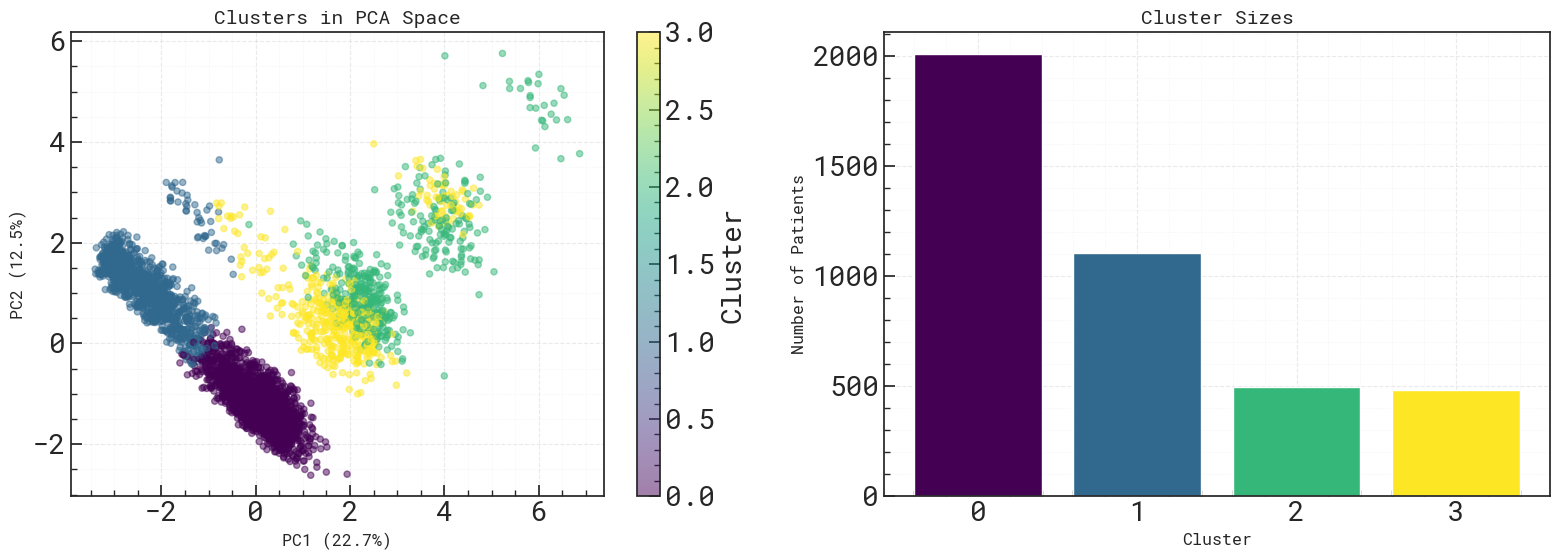


Running t-SNE (this may take a moment)...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

# Plot clusters in PCA space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                         cmap='viridis', alpha=0.5, s=20)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[0].set_title('Clusters in PCA Space', fontsize=14)
plt.colorbar(scatter, ax=axes[0], label='Cluster')
styling.style_ax(axes[0])

# Cluster sizes
cluster_sizes = df['cluster'].value_counts().sort_index()
axes[1].bar(cluster_sizes.index, cluster_sizes.values, color=plt.cm.viridis(np.linspace(0, 1, optimal_k)))
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Number of Patients', fontsize=12)
axes[1].set_title('Cluster Sizes', fontsize=14)
axes[1].set_xticks(range(optimal_k))
styling.style_ax(axes[1])

plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# t-SNE visualization
print("\nRunning t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, 
                    cmap='viridis', alpha=0.5, s=20)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('Clusters in t-SNE Space', fontsize=14)
plt.colorbar(scatter, ax=ax, label='Cluster')
styling.style_ax(ax)
plt.tight_layout()
plt.savefig('cluster_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

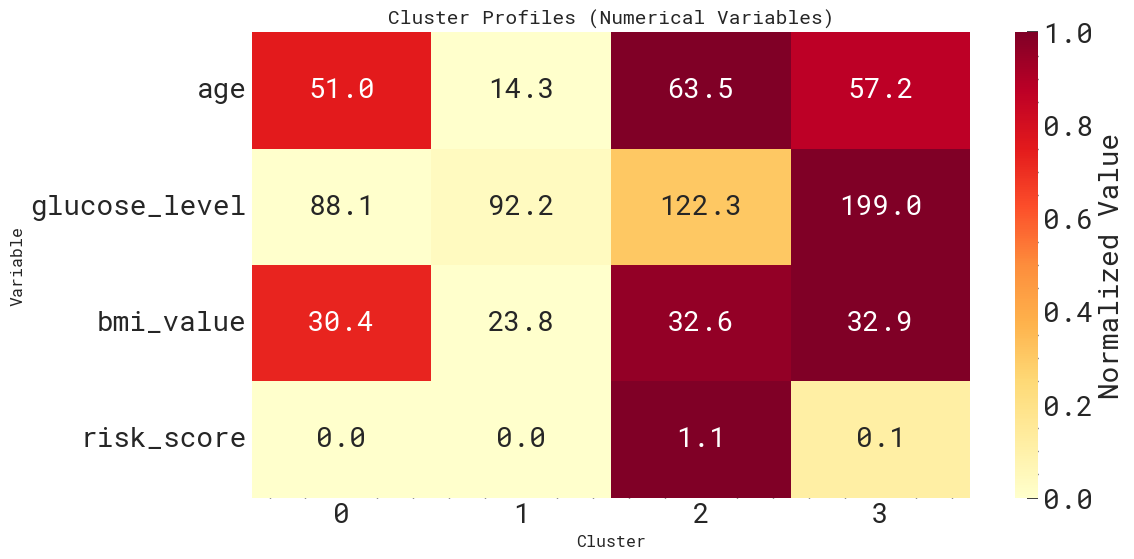

In [15]:
# Summary heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(12, 6))

# Normalize profiles for heatmap
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())
sns.heatmap(cluster_profiles_norm.T, annot=cluster_profiles.T.round(1), fmt='.1f',
            cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Normalized Value'})
ax.set_title('Cluster Profiles (Numerical Variables)', fontsize=14)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
styling.style_ax(ax, minor_grid=False)
plt.tight_layout()
plt.savefig('cluster_profiles_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
df.to_csv('clustered_data.csv', index=False)
print("\nClustered data saved to 'clustered_data.csv'")

# Save cluster profiles
cluster_profiles.to_csv('cluster_profiles.csv')
print("Cluster profiles saved to 'cluster_profiles.csv'")

# Final summary
print("\n" + "="*60)
print("CLUSTERING ANALYSIS SUMMARY")
print("="*60)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_scores[optimal_k-2]:.3f}")
print(f"Calinski-Harabasz Score: {calinski_scores[optimal_k-2]:.1f}")
print(f"Davies-Bouldin Score: {davies_bouldin_scores[optimal_k-2]:.3f}")
print("\nCluster sizes:")
for i in range(optimal_k):
    print(f"  Cluster {i}: {(cluster_labels == i).sum()} patients ({(cluster_labels == i).sum()/len(cluster_labels)*100:.1f}%)")


Clustered data saved to 'clustered_data.csv'
Cluster profiles saved to 'cluster_profiles.csv'

CLUSTERING ANALYSIS SUMMARY
Number of clusters: 4
Silhouette Score: 0.214
Calinski-Harabasz Score: 784.4
Davies-Bouldin Score: 1.631

Cluster sizes:
  Cluster 0: 2006 patients (49.1%)
  Cluster 1: 1104 patients (27.0%)
  Cluster 2: 494 patients (12.1%)
  Cluster 3: 484 patients (11.8%)
